# SI10-2026 | Ponderada | Análise de Sensibilidade em Métricas de Interface Digital

Nesta atividade, você vai analisar quais variáveis de uma interface digital têm maior impacto sobre a taxa de conversão.

A entrega deve ser feita neste notebook, com código, tabelas, gráficos e respostas curtas.

## Contexto

Uma equipe de produto quer decidir qual métrica de interface deve receber prioridade no próximo ciclo de melhoria.

Os dados representam observações diárias de um aplicativo de compras.

A métrica alvo é a taxa de conversão.

As variáveis de entrada são taxa de abandono do carrinho, profundidade média de scroll e tempo até o primeiro clique em produto.

## Preparação

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

pd.set_option("display.precision", 3)

## Dados

Execute a célula abaixo para criar a base da atividade.

In [2]:
rng = np.random.default_rng(42)
n_dias = 180

taxa_abandono = rng.normal(48, 8, n_dias).clip(25, 75)
profundidade_scroll = rng.normal(62, 12, n_dias).clip(25, 95)
tempo_primeiro_clique = rng.normal(7, 2.2, n_dias).clip(2, 15)

ruido = rng.normal(0, 0.35, n_dias)
taxa_conversao = (
    7.5
    - 0.055 * taxa_abandono
    + 0.026 * profundidade_scroll
    - 0.085 * tempo_primeiro_clique
    + ruido
).clip(0.5, 9.0)

df = pd.DataFrame({
    "data": pd.date_range("2026-01-01", periods=n_dias, freq="D"),
    "taxa_abandono_carrinho_pct": taxa_abandono,
    "profundidade_scroll_pct": profundidade_scroll,
    "tempo_primeiro_clique_s": tempo_primeiro_clique,
    "taxa_conversao_pct": taxa_conversao,
})

df.head()

,data,taxa_abandono_carrinho_pct,profundidade_scroll_pct,tempo_primeiro_clique_s,taxa_conversao_pct
0,2026-01-01,50.438,77.672,6.664,5.589
1,2026-01-02,39.680,64.633,7.843,6.042
2,2026-01-03,54.004,57.069,9.200,5.318
3,2026-01-04,55.525,75.275,4.671,5.944
4,2026-01-05,32.392,67.145,6.725,6.804


## Parte 1: Exploração

Crie ao menos um gráfico ou tabela para investigar a relação entre as variáveis de entrada e a taxa de conversão.

In [3]:
# Use esta célula para criar sua análise exploratória.

colunas_numericas = [
    "taxa_abandono_carrinho_pct",
    "profundidade_scroll_pct",
    "tempo_primeiro_clique_s",
    "taxa_conversao_pct",
]

df[colunas_numericas].corr()

,taxa_abandono_carrinho_pct,profundidade_scroll_pct,tempo_primeiro_clique_s,taxa_conversao_pct
taxa_abandono_carrinho_pct,1.000,-0.068,-0.116,-0.643
profundidade_scroll_pct,-0.068,1.000,0.050,0.485
tempo_primeiro_clique_s,-0.116,0.050,1.000,-0.229
taxa_conversao_pct,-0.643,0.485,-0.229,1.000


/tmp/ipykernel_9472/4047693330.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


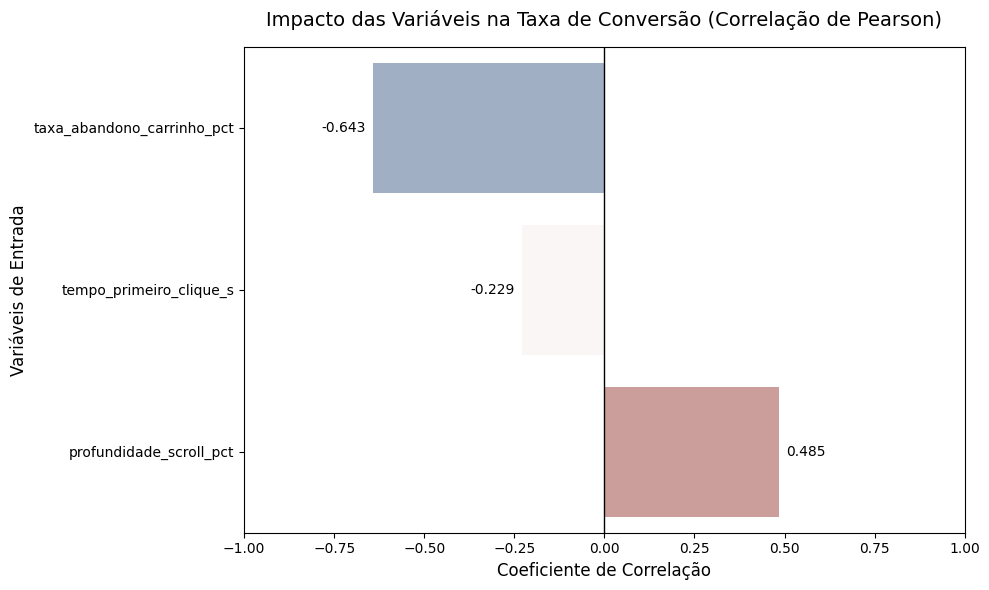

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolar as correlações em relação à taxa de conversão e remover a própria variável alvo
matriz_corr = df[colunas_numericas].corr()
corr_conversao = matriz_corr[['taxa_conversao_pct']].drop('taxa_conversao_pct')

# 2. Ordenar os valores para melhor visualização
corr_conversao = corr_conversao.sort_values(by='taxa_conversao_pct', ascending=True)

# 3. Criar o gráfico de barras
plt.figure(figsize=(10, 6))
grafico = sns.barplot(
    x=corr_conversao['taxa_conversao_pct'],
    y=corr_conversao.index,
    palette="vlag" # Uma paleta divergente (vermelho para negativo, azul para positivo) funciona bem aqui
)

# 4. Ajustes visuais
plt.title('Impacto das Variáveis na Taxa de Conversão (Correlação de Pearson)', fontsize=14, pad=15)
plt.xlabel('Coeficiente de Correlação', fontsize=12)
plt.ylabel('Variáveis de Entrada', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Linha no zero
plt.xlim(-1, 1) # Limitar o eixo X entre -1 e 1 (limites da correlação)

# Adicionar os rótulos de dados nas barras
for container in grafico.containers:
    grafico.bar_label(container, fmt='%.3f', padding=5)

plt.tight_layout()
plt.show()

In [21]:
# Preencha com uma variável de entrada para visualizar.
# Use exatamente um dos nomes que aparecem em features.

features = [
    "taxa_abandono_carrinho_pct",
    "profundidade_scroll_pct",
    "tempo_primeiro_clique_s",
]


variavel_x = "taxa_abandono_carrinho_pct"

fig = px.scatter(
    df,
    x=variavel_x,
    y="taxa_conversao_pct",
    title="Relação com a taxa de conversão",
)
fig.show()

In [22]:
variavel_x2 = "profundidade_scroll_pct"

fig = px.scatter(
    df,
    x=variavel_x2,
    y="taxa_conversao_pct",
    title="Relação com a taxa de conversão",
)
fig.show()

Escreva quais duas variáveis você escolheu para a análise de sensibilidade e justifique com evidências da exploração.

**Resposta:**

As variáveis escolhidas para a análise são taxa_abandono_carrinho_pct e profundidade_scroll_pct. A taxa de abandono foi selecionada por causar o maior impacto na queda da conversão, evidência comprovada matematicamente por sua forte correlação negativa de 0.643 e visualmente pela nítida tendência decrescente no gráfico de dispersão. Por outro lado, a profundidade do scroll foi escolhida por apresentar a maior correlação positiva do conjunto de dados, registrando 0.485, sendo o indicador de comportamento que mais impulsiona o aumento direto nas conversões.

## Parte 2: Modelo

Ajuste o modelo abaixo para estimar a taxa de conversão a partir das variáveis de entrada.

In [27]:
features_escolhidas = [
    "taxa_abandono_carrinho_pct",
    "profundidade_scroll_pct",
]
target = "taxa_conversao_pct"

X = df[features_escolhidas].to_numpy()
y = df[target].to_numpy()

X_design = np.column_stack([np.ones(len(X)), X])

coeficientes, *_ = np.linalg.lstsq(X_design, y, rcond=None)

pred = X_design @ coeficientes
erro = y - pred

mae = np.mean(np.abs(erro))
rmse = np.sqrt(np.mean(erro ** 2))

pd.DataFrame({
    "métrica": ["MAE", "RMSE"],
    "valor": [mae, rmse],
})

,métrica,valor
0,MAE,0.317
1,RMSE,0.402


Interprete o erro do modelo em relação à taxa de conversão.

**Resposta:**

O Erro Absoluto Médio (MAE) indica que as estimativas do modelo desviam, em média, apenas 0,317 pontos percentuais da taxa de conversão real. A Raiz do Erro Quadrático Médio (RMSE) atingiu 0,402, e, por estar com um valor próximo ao do MAE, demonstra que o modelo é consistente e não comete erros extremos ou discrepantes nas suas previsões. Na prática, ao simplificar o modelo para usar apenas as duas variáveis de maior impacto (abandono de carrinho e profundidade de scroll), a margem de erro se manteve baixa e segura, inferior a meio ponto percentual, confirmando que a equação é confiável e precisa para prever a taxa de conversão.

## Parte 3: Análise de Sensibilidade

Calcule a sensibilidade para duas variáveis de entrada usando uma variação de 10%.

Use a fórmula: sensibilidade igual à variação percentual da saída dividida pela variação percentual da entrada.

In [28]:
def prever_linha(linha):
    entrada = np.array([1] + [linha[features_escolhidas] for features_escolhidas in features_escolhidas])
    return float(entrada @ coeficientes)


linha_base = df[features_escolhidas].mean().to_dict()
saida_base = prever_linha(linha_base)

linha_base, saida_base

({'taxa_abandono_carrinho_pct': 47.54587889307049,
  'profundidade_scroll_pct': 62.44918010647032},
 5.868747841831929)

In [29]:
# Preencha com duas variáveis escolhidas na Parte 1.
# Use exatamente os nomes que aparecem em features.

variaveis_escolhidas = ["taxa_abandono_carrinho_pct",
                        "profundidade_scroll_pct"]

if len(variaveis_escolhidas) != 2:
    raise ValueError("Preencha variaveis_escolhidas com duas variáveis da lista features.")

variaveis_invalidas = [v for v in variaveis_escolhidas if v not in features]

if variaveis_invalidas:
    raise ValueError(f"Variáveis fora de features: {variaveis_invalidas}")

variacao_entrada = 0.10

resultados = []

for variavel in variaveis_escolhidas:
    linha_cenario = linha_base.copy()
    valor_original = linha_base[variavel]
    valor_alterado = valor_original * (1 + variacao_entrada)
    linha_cenario[variavel] = valor_alterado

    saida_nova = prever_linha(linha_cenario)
    variacao_saida = (saida_nova - saida_base) / saida_base
    indice_sensibilidade = variacao_saida / variacao_entrada

    resultados.append({
        "variável": variavel,
        "valor_original": valor_original,
        "valor_alterado": valor_alterado,
        "saída_original": saida_base,
        "saída_nova": saida_nova,
        "variação_saida_pct": variacao_saida * 100,
        "índice_sensibilidade": indice_sensibilidade,
    })

tabela_sensibilidade = pd.DataFrame(resultados)
tabela_sensibilidade

,variável,valor_original,valor_alterado,saída_original,saída_nova,variação_saida_pct,índice_sensibilidade
0,taxa_abandono_carrinho_pct,47.546,52.300,5.869,5.598,-4.612,-0.461
1,profundidade_scroll_pct,62.449,68.694,5.869,6.015,2.499,0.250


Compare os índices de sensibilidade e indique qual variável tem maior impacto sobre a taxa de conversão.

Mostre o raciocínio: cite os valores da tabela e explique o que eles significam para a decisão.

**Resposta:**

A variável com o maior impacto sobre a taxa de conversão é a taxa_abandono_carrinho_pct.

É possível comprovar isso observando o índice de sensibilidade na tabela, que mede a força de cada variável no resultado final.

- A taxa de abandono possui um índice de 0.461 negativo. O seu valor absoluto é quase o dobro da outra métrica. Na prática, ao simularmos um aumento de 10 por cento no abandono, a conversão sofreu uma queda brusca de 4.612 por cento.

- A profundidade do scroll possui um índice de 0.250 positivo. Aplicando os mesmos 10 por cento de aumento no engajamento de página, o ganho na conversão foi de apenas 2.499 por cento.

Portanto, a magnitude do impacto do abandono de carrinho supera consideravelmente o engajamento por scroll. Nossa prioridade técnica e analítica deve ser investigar e mitigar a perda de usuários durante a etapa do carrinho, pois é a alavanca mais sensível para melhorar nossos resultados.

## Parte 4: Decisão

Recomende uma ação de produto ou interface com base na análise.

Sua recomendação deve citar os números da tabela de sensibilidade.

**Resposta:**

Com base na análise de sensibilidade, recomendo uma reformulação na interface do checkout para reduzir o atrito na etapa final, como a implementação de uma tela de pagamento em página única (one-page checkout) e a oferta clara da opção de compra como convidado, sem a obrigatoriedade de criação de conta prévia.

A justificativa técnica para priorizar essa ação no produto baseia-se diretamente nos números da tabela de sensibilidade. A taxa de abandono de carrinho registrou o maior índice de impacto, marcado em -0.461. A simulação provou que um aumento de 10% no abandono (elevando o valor de 47.546 para 52.300) causou uma queda de 4.612% na taxa de conversão, fazendo-a despencar de 5.869 para 5.598. Como o peso dessa perda é quase o dobro da alavancagem positiva promovida pela profundidade do scroll (que tem índice de 0.250 e variação de apenas 2.499%), qualquer esforço da equipe de design e engenharia para facilitar a interface do carrinho protegerá a métrica mais sensível do sistema, resultando no maior retorno financeiro direto.

*Aponte* uma limitação, risco ou hipótese da sua análise.

**Resposta:**

**Limitação principal:** O viés de variável omitida e a confusão entre correlação e causalidade.

A análise matemática prova que a taxa de abandono de carrinho tem o maior peso estatístico sobre a queda na conversão, mas ela apresenta a limitação de não conseguir diagnosticar o *motivo* real desse abandono. O modelo linear assumiu a hipótese de que essas métricas operam num ambiente perfeitamente isolado.

O risco prático de basear a tomada de decisão exclusivamente nesta regressão é o de investirmos tempo de desenvolvimento melhorando a interface e o fluxo do carrinho, e ainda assim não obter a recuperação de 4.6% projetada na sensibilidade. Isso acontecerá se a verdadeira causa do abandono for um fator externo que foi omitido da base de dados original, como um susto com um custo de frete abusivo no último segundo, prazo de entrega muito longo ou falta de opções de pagamento.

Nesse cenário, o número de abandono de carrinho é apenas o sintoma do problema, e não a causa; logo, otimizar apenas a fluidez da tela não corrigirá a taxa de conversão final.

## Ao Além dos Aléns

Faça uma simulação de Monte Carlo para estimar como a taxa de conversão pode variar sob incerteza nas variáveis de entrada.

In [33]:
# Use esta célula para sua simulação.

n_simulacoes = 1000

amostras = pd.DataFrame({
    "taxa_abandono_carrinho_pct": rng.normal(
        linha_base["taxa_abandono_carrinho_pct"], 5, n_simulacoes
    ).clip(25, 75),
    "profundidade_scroll_pct": rng.normal(
        linha_base["profundidade_scroll_pct"], 8, n_simulacoes
    ).clip(25, 95),
})

amostras_design = np.column_stack([
    np.ones(len(amostras)),
    amostras[features_escolhidas].to_numpy(),
])
previsoes = amostras_design @ coeficientes

pd.Series(previsoes).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

,0
count,1000.000
mean,5.875
std,0.343
min,4.730
10%,5.449
25%,5.641
50%,5.865
75%,6.126
90%,6.307
max,7.105


In [34]:
fig = px.histogram(
    pd.DataFrame({"taxa_conversao_pct_prevista": previsoes}),
    x="taxa_conversao_pct_prevista",
    nbins=30,
    title="Distribuição simulada da taxa de conversão",
)
fig.show()

Interprete o que a distribuição simulada indica sobre o risco da sua recomendação.

**Resposta:**

A distribuição simulada de Monte Carlo indica que **o risco de investir na recomendação é baixo e o cenário é altamente previsível.**

A simulação introduziu incerteza (variações aleatórias nas métricas de abandono e scroll) para testar o que aconteceria com a conversão no mundo real, onde os dias não são todos iguais. O resultado prova que a nossa taxa de conversão não é volátil ou caótica.

**Evidências nos dados:**

* **Estabilidade central:** A média das 1000 simulações (5.875%) ficou praticamente idêntica à conversão base original, com um desvio padrão muito pequeno (0.343).
* **Risco contido:** Observando os percentis de 10% e 90%, fica claro que em 80% dos cenários simulados a conversão flutua dentro de uma faixa bem estreita e segura, entre 5.44% e 6.30%.
* **Comportamento visual:** O histograma concentra a esmagadora maioria dos resultados no meio, formando uma curva de sino previsível e sem extremos (caudas) frequentes ou alarmantes.

**O que isso significa para a decisão:**
Como o sistema é estatisticamente estável, as flutuações naturais do dia a dia não vão "engolir" os resultados do seu trabalho. Isso garante que, se a recomendação for aplicada e o produto conseguir de fato reduzir a taxa de abandono na interface, você verá o impacto real: toda essa curva do gráfico será empurrada para a direita, gerando um ganho de conversão sólido e fácil de medir.

## Política de Uso de IA

O uso de IA é permitido para apoio técnico, revisão de texto e estudo dos conceitos.

As escolhas de variáveis, os cálculos, a comparação dos índices e a recomendação devem refletir sua análise dos resultados deste notebook.

Você deve ser capaz de explicar qualquer resposta entregue.

Respostas sem relação com os números gerados, com indícios de cópia ou que não possam ser justificadas poderão ser tratadas como fora da proposta.

## Instruções de entrega

A entrega deverá ser feita no GitHub ou no próprio Google Colab.

Links **sem permissão** de acesso terão um desconto de 20% na nota.